<a href="https://colab.research.google.com/github/sergiomora03/AdvancedTopicsAnalytics/blob/main/exercises/E5-NeuralNetworksKeras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<small>**NOTE: This notebook was created using a Miniconda environment with Python 3.12.2 and IPykernel for local development with Visual Studio Code.**</small>

# Excercise 5
## Neural Networks in Keras and Pytorch 🔥

Use keras framework to solve the below exercises.


In [26]:
try:
    import numpy as np
except ImportError as e:
    error = str(e)
    lib = error.split()[-1].replace("'", "")
    print(f"\033[32mIntalling {lib}\033[0m")
    !pip install numpy==2.1.3
    import numpy as np

try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
except ImportError as e:
    error = str(e)
    lib = error.split()[-1].replace("'", "")
    print(f"\033[32mIntalling {lib}\033[0m")
    !pip install tensorflow==2.19.0
    from tensorflow.keras.models import Sequential

try:
    from keras_tuner import HyperModel
    from keras_tuner.tuners import RandomSearch, Hyperband
except ImportError as e:
    error = str(e)
    lib = error.split()[-1].replace("'", "")
    print(f"\033[32mIntalling {lib}\033[0m")
    !pip install keras-tuner==1.4.7
    from keras_tuner import HyperModel
    from keras_tuner.tuners import RandomSearch, Hyperband

try:
    import keras
except ImportError as e:
    error = str(e)
    lib = error.split()[-1].replace("'", "")
    print(f"\033[32mIntalling {lib}\033[0m")
    !pip install keras==3.9.0
    import keras

try:
    import pandas as pd
except ImportError as e:
    error = str(e)
    lib = error.split()[-1].replace("'", "")
    print(f"\033[32mIntalling {lib}\033[0m")
    !pip install pandas==2.2.3
    import pandas as pd

try:
    import matplotlib.pyplot as plt
except ImportError as e:
    error = str(e)
    lib = error.split()[-1].replace("'", "")
    print(f"\033[32mIntalling {lib}\033[0m")
    !pip install matplotlib==3.10.0
    import matplotlib.pyplot as plt

try:
    from sklearn.datasets import make_moons
except ImportError as e:
    error = str(e)
    lib = error.split()[-1].replace("'", "")
    print(f"\033[32mIntalling {lib}\033[0m")
    !pip install scikit-learn==1.6.1
    from sklearn.datasets import make_moons

try:
    from livelossplot import PlotLossesKeras
except ImportError as e:
    error = str(e)
    lib = error.split()[-1].replace("'", "")
    print(f"\033[32mIntalling {lib}\033[0m")
    !pip install livelossplot==0.5.6
    from livelossplot import PlotLossesKeras

In [27]:
%load_ext tensorboard

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


# 5 Moons Dataset

**Exercise:** Use keras and pytorch framework to find a decision boundary for point in the make_moons.

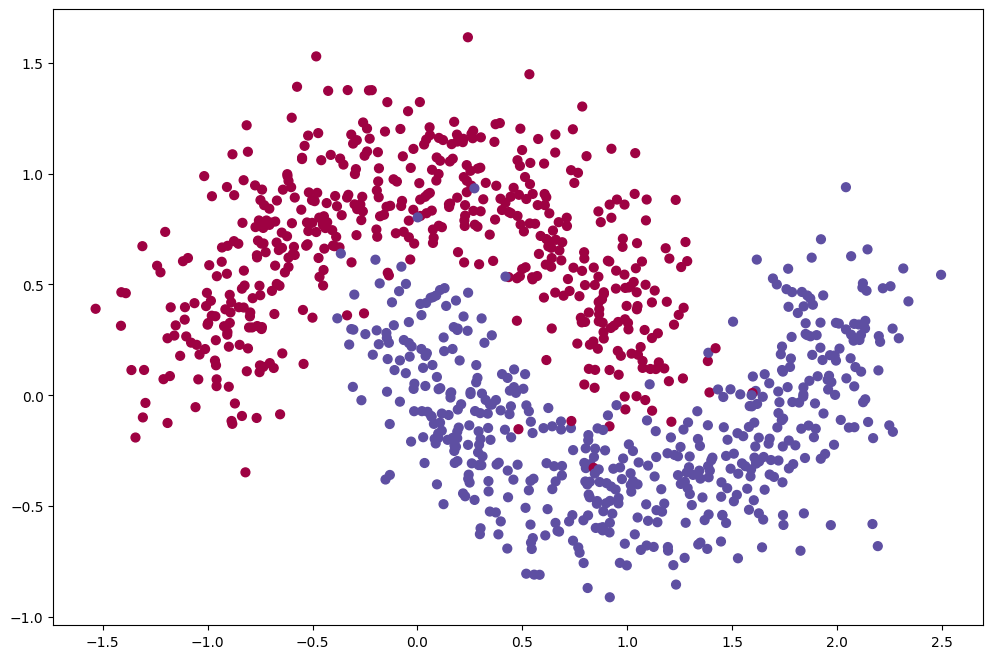

In [28]:
# Create moons dataset.
x_train, y_train = make_moons(n_samples=1000, noise= 0.2, random_state=3)

def plot_data(x_train, y_train):
    plt.figure(figsize=(12, 8))
    plt.scatter(x_train[:, 0], x_train[:,1], c=y_train, s=40, cmap=plt.cm.Spectral);

plot_data(x_train, y_train)

# 5.1 Decision Boundary -- Keras

**Exercise:** Use keras framework to find a decision boundary for point in the make_moons.

In [29]:
class nnModel(HyperModel):

    def __init__(self, min_layers, max_layers, min_dropout, max_dropout, step_dropout, 
                 min_nuerons, max_neurons, min_learning_rate, max_learning_rate, seed):
        self.min_layers = min_layers
        self.max_layers = max_layers
        self.min_dropout = min_dropout
        self.max_dropout = max_dropout
        self.step_dropout = step_dropout
        self.min_neurons = min_nuerons
        self.max_neurons = max_neurons
        self.min_learning_rate = min_learning_rate
        self.max_learning_rate = max_learning_rate
        self.seed = seed
    def build(self, hp):
        
        NUM_LAYERS = hp.Int("num_layers", self.min_layers, self.max_layers)
        DROPOUT_RATE = hp.Float("dropout_rate", self.min_dropout, self.max_dropout, self.step_dropout)
        NUM_NEURONS = hp.Int("num_nuerons", self.min_neurons, self.max_neurons, step=1)
        LEARNING_RATE = hp.Float("learning_rate", self.min_learning_rate, self.max_learning_rate,
                                 sampling='log')
        model = Sequential()

        for i in range(NUM_LAYERS):
            
            model.add(keras.layers.Dense(units=NUM_NEURONS, activation='relu'))

            model.add(keras.layers.Dropout(rate=DROPOUT_RATE, seed=self.seed))
        
        model.add(keras.layers.Dense(units=1, activation='sigmoid'))
        model.compile(
            optimizer=tf.keras.optimizers.Adam(LEARNING_RATE),
            loss="binary_crossentropy",
            metrics=["accuracy"]
        )

        return model

- Instantiate the nnModel object with the tunning parameters 

In [30]:
tuned_model =  nnModel(1, 5, 0.1, 0.5, 0.1, 2, 10, 1e-4, 1e-2, 2)
tuner = Hyperband(tuned_model,
                  objective='val_accuracy',
                  max_epochs=50,
                  directory="tuner_results",
                  project_name="fashion_mnist")
early_stopping_callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir="logs")

- Hyperparameter search

In [31]:
tuner.search(x_train, y_train, epochs=50, validation_split=0.2, callbacks=[early_stopping_callback, tensorboard_callback])

Trial 90 Complete [00h 00m 09s]
val_accuracy: 0.7450000047683716

Best val_accuracy So Far: 0.9850000143051147
Total elapsed time: 00h 04m 22s


In [39]:
%tensorboard --logdir logs

{'num_layers': 4, 'dropout_rate': 0.2, 'num_nuerons': 9, 'learning_rate': 0.009476417602900553, 'tuner/epochs': 50, 'tuner/initial_epoch': 17, 'tuner/bracket': 3, 'tuner/round': 3, 'tuner/trial_id': '0046'}
Epoch 1/70
115/115 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6592 - loss: 0.6237 - val_accuracy: 0.8900 - val_loss: 0.2640
Epoch 2/70
115/115 ━━━━━━━━━━━━━━━━━━━━ -0s -3897us/step - accuracy: 0.8847 - loss: 0.3200 - val_accuracy: 0.9400 - val_loss: 0.1670
Epoch 3/70
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9030 - loss: 0.2936 - val_accuracy: 0.9250 - val_loss: 0.1895
Epoch 4/70
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9143 - loss: 0.1942 - val_accuracy: 0.9650 - val_loss: 0.1252
Epoch 5/70
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9136 - loss: 0.2352 - val_accuracy: 0.9350 - val_loss: 0.1775
Epoch 6/70
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9026 - loss: 0.2198 - val_accuracy: 0.9450 - val_loss: 0.1462
Epoch 7/70
115/115 ━

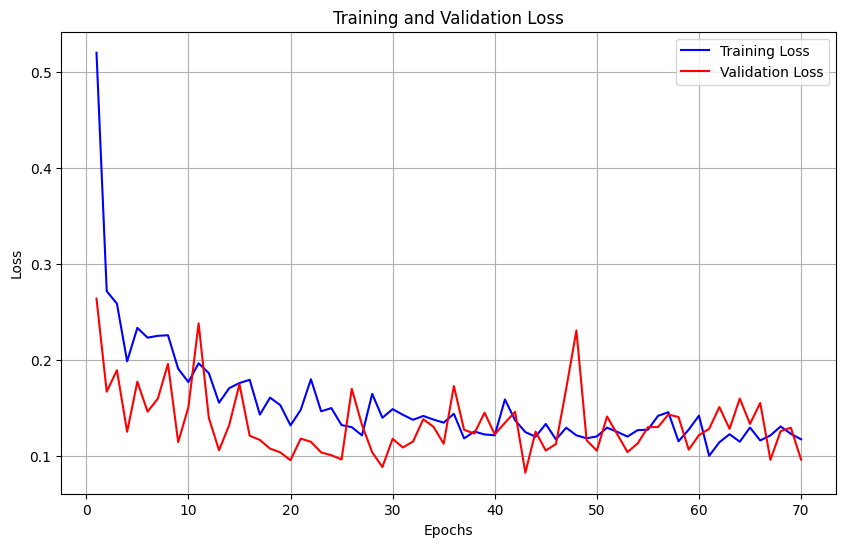

In [33]:
best_hps = tuner.get_best_hyperparameters(num_trials=5)[0]
print(best_hps.values)
model = tuner.hypermodel.build(best_hps)
hp_history = model.fit(x_train, y_train, validation_split=0.2, batch_size=7, epochs=70, verbose=1)

train_loss = hp_history.history['loss']
val_loss = hp_history.history['val_loss']
epochs = range(1, len(train_loss) + 1)

# Plot the loss curves
plt.figure(figsize=(10, 6))
plt.plot(epochs, train_loss, 'b', label='Training Loss')  # 'b' for blue line
plt.plot(epochs, val_loss, 'r', label='Validation Loss')  # 'r' for red line
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)

plt.show()

In [40]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 9)              │            27 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 9)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 9)              │            90 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 9)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 9)              │            90 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 9)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 9)              │            90 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 9)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │            10 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 923 (3.61 KB)

 Trainable params: 307 (1.20 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 616 (2.41 KB)

**Hint:** Use the next function to plt the decision boundary,

Epoch 1/43
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9726 - loss: 0.1184 - val_accuracy: 0.9800 - val_loss: 0.1123
Epoch 2/43
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9580 - loss: 0.1432 - val_accuracy: 0.9700 - val_loss: 0.1208
Epoch 3/43
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9678 - loss: 0.1101 - val_accuracy: 0.9750 - val_loss: 0.1250
Epoch 4/43
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9639 - loss: 0.1175 - val_accuracy: 0.9600 - val_loss: 0.1244
Epoch 5/43
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9725 - loss: 0.0886 - val_accuracy: 0.9650 - val_loss: 0.1025
Epoch 6/43
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9712 - loss: 0.1054 - val_accuracy: 0.9650 - val_loss: 0.1446
Epoch 7/43
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9659 - loss: 0.0910 - val_accuracy: 0.9700 - val_loss: 0.1481
Epoch 8/43
115/115 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9528 - loss: 0.1042 - val_accuracy: 0.

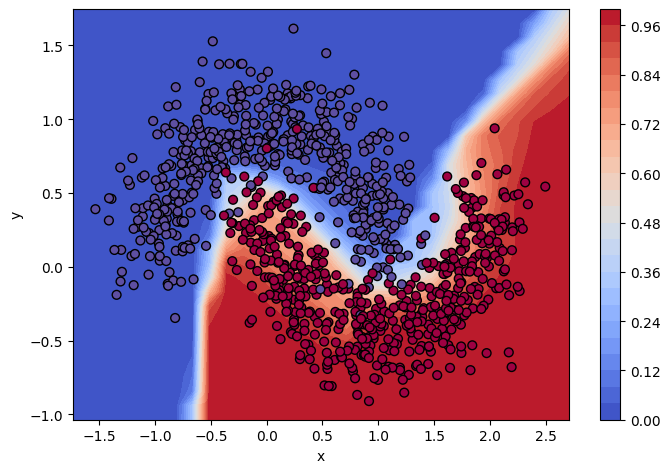

In [41]:
# Train the model using the optimal number of epochs.
model.fit(x_train, y_train, validation_split=0.2, batch_size=7, epochs=43, verbose=1)

def model_train(X, y):
    model = Sequential()
    return model

def plot_decision_region(model, X, pred_fun, y):
    min_x = np.min(X[:, 0])
    max_x = np.max(X[:, 0])
    min_y = np.min(X[:, 1])
    max_y = np.max(X[:, 1])
    min_x = min_x - (max_x - min_x) * 0.05
    max_x = max_x + (max_x - min_x) * 0.05
    min_y = min_y - (max_y - min_y) * 0.05
    max_y = max_y + (max_y - min_y) * 0.05
    x_vals = np.linspace(min_x, max_x, 30)
    y_vals = np.linspace(min_y, max_y, 30)
    XX, YY = np.meshgrid(x_vals, y_vals)
    grid_r, grid_c = XX.shape
    ZZ = np.zeros((grid_r, grid_c))
    for i in range(grid_r):
        for j in range(grid_c):
            '''
            Here 'model' is the neural network you previous trained.
            '''
            ZZ[i, j] = pred_fun(model, XX[i, j], YY[i, j])
    plt.contourf(XX, YY, ZZ, 30, cmap = plt.cm.coolwarm, vmin= 0, vmax=1)
    plt.colorbar()
    plt.scatter(X[:, 0], x_train[:, 1], c=y, s=40, cmap=plt.cm.Spectral.reversed(), edgecolors='k')
    plt.xlabel("x")
    plt.ylabel("y")

def pred_fun(model,x1, x2):
    '''
    Here 'model' is the neural network you previous trained.
    '''
    xval = np.array([[x1, x2]])
    return model.predict(xval)[0, 0]

plt.figure(figsize = (8,16/3))
'''
Here 'model' is the neural network you previous trained.
'''
plot_decision_region(model, x_train, pred_fun, y_train)

# 5.2 Decision Boundary -- PyTorch 🔥

**Exercise:** Use PyTorch to find a decision boundary for point in the make_moons.

**Hint:** Use the next function to plt the decision boundary,

In [ ]:
model = 'Sequential neural network in PyTorch'

def plot_decision_region(model, X, pred_fun):
    min_x = np.min(X[:, 0])
    max_x = np.max(X[:, 0])
    min_y = np.min(X[:, 1])
    max_y = np.max(X[:, 1])
    min_x = min_x - (max_x - min_x) * 0.05
    max_x = max_x + (max_x - min_x) * 0.05
    min_y = min_y - (max_y - min_y) * 0.05
    max_y = max_y + (max_y - min_y) * 0.05
    x_vals = np.linspace(min_x, max_x, 30)
    y_vals = np.linspace(min_y, max_y, 30)
    XX, YY = np.meshgrid(x_vals, y_vals)
    grid_r, grid_c = XX.shape
    ZZ = np.zeros((grid_r, grid_c))
    for i in range(grid_r):
        for j in range(grid_c):
            '''
            Here 'model' is the neural network you previous trained.
            '''
            ZZ[i, j] = pred_fun(model, XX[i, j], YY[i, j])
    plt.contourf(XX, YY, ZZ, 30, cmap = pl.cm.coolwarm, vmin= 0, vmax=1)
    plt.colorbar()
    plt.xlabel("x")
    plt.ylabel("y")

def pred_fun(model,x1, x2):
    '''
    Here 'model' is the neural network you previous trained.
    '''
    xval = np.array([[x1, x2]])
    return model.predict(xval)[0, 0]

plt.figure(figsize = (8,16/3))
'''
Here 'model' is the neural network you previous trained.
'''
plot_decision_region(model, x_train, pred_fun)
plot_data(x_train, y_train)

AttributeError: 'str' object has no attribute 'predict'

<Figure size 800x533.333 with 0 Axes>